# Análisis Exploratorio de Datos - Campañas de Marketing Bancario

El objetivo de este proyecto es limpiar y analizar los datos de campañas de marketing de una entidad bancaria para identificar patrones y factores que influyen en la contratación de productos.

1. IMPORTACIÓN DE LIBRERÍAS

Primero, instalar pandas (y openpyxl), matplotlib y seaborn en la terminal con pip install, luego importar las librerías necesarias:

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. CARGA DE DATOS

In [4]:
df = pd.read_csv("../data/RAW/bank-additional.csv")
excel = pd.ExcelFile("../data/RAW/customer-details.xlsx")

df1 = pd.read_excel(excel, sheet_name=0)
df2 = pd.read_excel(excel, sheet_name=1)
df3 = pd.read_excel(excel, sheet_name=2)

df_clientes = pd.concat([df1, df2, df3])

3. EXPLORACIÓN INICIAL

En este apartado, el objetivo es tener una imágen clara sobre las BBDD, sus columnas, valores y formatos, para poder realizar la limpieza correspondiente. Para ello, usamos funcionemos como head, info, describe. En este punto, también podemos detectar la cantidad de nulos por columna con los que vamos a trabajar, y así determinar el tratamiento que se le dará a cada uno.

In [5]:
df.columns

Index(['Unnamed: 0', 'age', 'job', 'marital', 'education', 'default',
       'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude',
       'longitude', 'id_'],
      dtype='object')

In [6]:
df_clientes.columns

Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'NumWebVisitsMonth', 'ID'],
      dtype='object')

In [7]:
df.shape

(43000, 24)

In [8]:
df_clientes.shape

(43170, 7)

In [9]:
df.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [10]:
df_clientes.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  object 
 3   marital         42915 non-null  object 
 4   education       41193 non-null  object 
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  object 
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  object 
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  object 
 16  cons.conf.idx   43000 non-null  object 
 17  euribor3m       33744 non-null 

In [12]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43170 entries, 0 to 14089
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[ns]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 2.6+ MB


In [13]:
df.describe()

,Unnamed: 0,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude
count,43000.000000,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,20651.099047,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,36.856697,-95.939067
std,11868.770913,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,7.225948,16.752282
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,24.396000,-124.997000
25%,10381.750000,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,30.614750,-110.494250
50%,20642.500000,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,36.761000,-95.899500
75%,30930.250000,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,43.113250,-81.427750
max,41187.000000,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,49.384000,-66.937000


In [14]:
df_clientes.describe()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
count,43170.000000,43170.000000,43170.000000,43170.000000,43170,43170.000000
mean,7916.022469,93227.389622,1.004749,0.998633,2013-05-11 22:09:47.407922176,16.591290
min,0.000000,5841.000000,0.000000,0.000000,2012-01-01 00:00:00,1.000000
25%,3597.000000,49608.000000,0.000000,0.000000,2012-07-16 00:00:00,9.000000
50%,7194.500000,93009.500000,1.000000,1.000000,2013-03-01 00:00:00,17.000000
75%,11705.750000,136740.500000,2.000000,2.000000,2014-03-28 00:00:00,25.000000
max,20114.000000,180802.000000,2.000000,2.000000,2014-12-31 00:00:00,32.000000
std,5228.248885,50498.181989,0.815996,0.816008,NaN,9.241769


In [15]:
df[df.duplicated()]

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_


In [16]:
df_clientes[df_clientes.duplicated()]

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID


In [17]:
df.isnull().sum()

Unnamed: 0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [18]:
df_clientes.isnull().sum()

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

4. LIMPIEZA INICIAL

Cuando ya tenemos claro los valores con los que trabajamos, nos centramos en que cada uno tenga el formato correspondiente y eliminamos las columnas que no aporten al análisis.

In [19]:
# Eliminar la columna "Unnamed: 0", índice innecesario
df = df.drop(columns=["Unnamed: 0"])
df_clientes = df_clientes.drop(columns=["Unnamed: 0"])

In [20]:
# Cambiar el nombre de las columnas para un mejor manejo de las tablas
df.rename(columns={"id_": "ID"}, inplace=True)
df.rename(columns={"y": "Conversion"}, inplace=True)

In [21]:
# Convertir la variable objetivo "y" a numérica, donde "yes" se convierte en 1 y "no" en 0 para facilitar el análisis.
df["Conversion"] = df["Conversion"].map({"yes": 1, "no": 0})

In [22]:
# Convertir los valores de las columnas numéricas a tipo numérico, ya que al leer el CSV se interpretaron como objetos (strings), en el excel los formatos están correctos.
cols = ["cons.price.idx", "cons.conf.idx", "euribor3m"]

for col in cols:
    df[col] = df[col].str.replace(",", ".").astype(float)

# Tuve que reemplazar las comas por puntos para convertir los valores a tipo numérico, ya que en el CSV los números decimales estaban representados con comas, por lo que me daba error al intentar convertirlos directamente a float.

In [23]:
# Convertir la columna "date" a formato datetime, primero traduciendo los meses del español al inglés para que pandas pueda interpretarlos correctamente.
meses = {
    'enero': 'Jan', 'febrero': 'Feb', 'marzo': 'Mar', 'abril': 'Apr',
    'mayo': 'May', 'junio': 'Jun', 'julio': 'Jul', 'agosto': 'Aug',
    'septiembre': 'Sep', 'octubre': 'Oct', 'noviembre': 'Nov', 'diciembre': 'Dec'
}

df['date_en'] = df['date']
for es, en in meses.items():
    df['date_en'] = df['date_en'].str.replace(es, en, regex=True)

df['date'] = pd.to_datetime(df['date_en'], dayfirst=True)

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()

df.drop(columns=['date_en'], inplace=True)

# En este punto me dio error al intentar convertir la columna "date" a formato datetime, ya que los meses estaban en español y pandas no los reconocía. Por eso tuve que crear una nueva columna "date_en" donde reemplacé los nombres de los meses en español por sus equivalentes en inglés, para luego poder convertir esa columna a datetime sin problemas. Después extraje el año, mes, día y día de la semana en nuevas columnas para facilitar el análisis temporal. Finalmente eliminé la columna "date_en" ya que solo era un paso intermedio para la conversión.


In [24]:
# En la tabla de df_clientes, la columna "Dt_Customer" ya está en formato datetime, así que solo necesito extraer el día, mes y año en nuevas columnas para facilitar el análisis temporal.

df_clientes["day"] = df_clientes["Dt_Customer"].dt.day
df_clientes["month"] = df_clientes["Dt_Customer"].dt.month
df_clientes["year"] = df_clientes["Dt_Customer"].dt.year

In [25]:
# Verificamos los cambios realizados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   age             37880 non-null  float64       
 1   job             42655 non-null  object        
 2   marital         42915 non-null  object        
 3   education       41193 non-null  object        
 4   default         34019 non-null  float64       
 5   housing         41974 non-null  float64       
 6   loan            41974 non-null  float64       
 7   contact         43000 non-null  object        
 8   duration        43000 non-null  int64         
 9   campaign        43000 non-null  int64         
 10  pdays           43000 non-null  int64         
 11  previous        43000 non-null  int64         
 12  poutcome        43000 non-null  object        
 13  emp.var.rate    43000 non-null  float64       
 14  cons.price.idx  42529 non-null  float64       
 15  co

In [26]:
df.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,nr.employed,Conversion,date,latitude,longitude,ID,year,month,day,weekday
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,...,5191,0,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,2019.0,8.0,2.0,Friday
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,...,5191,0,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,2016.0,9.0,14.0,Wednesday


In [27]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43170 entries, 0 to 14089
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Income             43170 non-null  int64         
 1   Kidhome            43170 non-null  int64         
 2   Teenhome           43170 non-null  int64         
 3   Dt_Customer        43170 non-null  datetime64[ns]
 4   NumWebVisitsMonth  43170 non-null  int64         
 5   ID                 43170 non-null  object        
 6   day                43170 non-null  int32         
 7   month              43170 non-null  int32         
 8   year               43170 non-null  int32         
dtypes: datetime64[ns](1), int32(3), int64(4), object(1)
memory usage: 2.8+ MB


In [28]:
df_clientes.head(2)

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,day,month,year
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,4,4,2012
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,30,12,2012


5. MANEJO DE VALORES NULOS Y OUTLIERS

Para terminar con la limpieza de las tablas, es necesario tomar decisiones sobre el manejo de los valores nulos y outliers, ya que el correcto manejo de estos es escenial para el posterior análisis de los mismos.

In [29]:
# Para menajar los nulos en "age", decidí relacionarlo directamente con "marital", para ello, primero rellené los valores faltantes de "marital" con la moda.

df['marital'].fillna(df['marital'].mode()[0], inplace=True)

C:\Users\rscon\AppData\Local\Temp\ipykernel_10432\970925120.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['marital'].fillna(df['marital'].mode()[0], inplace=True)


In [30]:
# Para rellenar los valores nulos de "age", utilicé la función transform de pandas para aplicar una función lambda que rellena los valores faltantes con la mediana de "age" dentro de cada grupo de "marital". De esta manera, los valores nulos en "age" se rellenan de manera más precisa, teniendo en cuenta la relación entre el estado civil y la edad.
df['age'] = df.groupby('marital')['age'].transform(lambda x: x.fillna(x.median()))

In [31]:
# Para menajar los nulos de "job" y "education" decidí reemplazarlos por la palabra "unknown".

df['job'].fillna('unknown', inplace=True)
df['education'].fillna('unknown', inplace=True)

C:\Users\rscon\AppData\Local\Temp\ipykernel_10432\3587243606.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['job'].fillna('unknown', inplace=True)
C:\Users\rscon\AppData\Local\Temp\ipykernel_10432\3587243606.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [32]:
# Para los nulos de "default", "housing" y "loan", decidí rellenarlos con -1, ya que son variables binarias y no quiero introducir una categoría adicional como "unknown", además de que -1 me permitirá identificarlos fácilmente en el análisis posterior.

df['default'].fillna(-1, inplace=True)
df['housing'].fillna(-1, inplace=True)
df['loan'].fillna(-1, inplace=True)

C:\Users\rscon\AppData\Local\Temp\ipykernel_10432\1145854314.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['default'].fillna(-1, inplace=True)
C:\Users\rscon\AppData\Local\Temp\ipykernel_10432\1145854314.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [33]:
# Para manejar los nulos de "cons.price.idx", decidí rellenarlos con la media de la columna, ya que no son muchos nulos y la media es una buena opción para este tipo de variable numérica continua.

df['cons.price.idx'].fillna(df['cons.price.idx'].mean(), inplace=True)

C:\Users\rscon\AppData\Local\Temp\ipykernel_10432\3306233650.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cons.price.idx'].fillna(df['cons.price.idx'].mean(), inplace=True)


In [34]:
# Para manejar los nulos de la columna "date", al ser un dato importante para el análisis temporal, y al ser tan poco nulos (248 nulos, el 0.5% del total de filas), decidí eliminar las filas que contienen nulos en esta columna, ya que no afectará significativamente el análisis y me permitirá trabajar con datos completos en las fechas.

df = df.dropna(subset=['date'])

In [35]:
# Para manejar los nulos en la columna "euribor3m", decidí rellenarlos con el último valor conocido, ordenando primero de forma descendente la columna "cons.price.idx".

df = df.sort_values('cons.price.idx', ascending=False)
df['euribor3m'] = df['euribor3m'].fillna(method='ffill')

C:\Users\rscon\AppData\Local\Temp\ipykernel_10432\54630477.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['euribor3m'] = df['euribor3m'].fillna(method='ffill')


In [36]:
#Comprobamos los nulos después de la limpieza
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
Conversion        0
date              0
latitude          0
longitude         0
ID                0
year              0
month             0
day               0
weekday           0
dtype: int64

6. UNIR LAS TABLAS

Una vez finalizada la limpieza de las tablas, es necesario unirlas por el "ID", para poder extraer mayor información.

In [37]:
# Realizamos un left join debido a que queremos conservar todas las filas de df (tabla principal) y agregar la información de df_clientes (tabla secundaria) donde coincidan los IDs, pero sin eliminar filas de df que no tengan correspondencia.

df_limpio = df.merge(df_clientes, on='ID', how='left')

In [38]:
# Verificamos que el merge se haya realizado correctamente y que no haya columnas duplicadas ni conflictos de nombres.
df_limpio.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'Conversion', 'date', 'latitude', 'longitude', 'ID',
       'year_x', 'month_x', 'day_x', 'weekday', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth', 'day_y', 'month_y',
       'year_y'],
      dtype='object')

7. DESCARGA ARCHIVOS LIMPIOS

Finalmente, antes de pasar al EDA, descargamos los archivos limpios y los guardamos en una carpeta para tenerlos disponible para futuros análisis. 

In [39]:
df.to_csv("../data/Procesado/bank-additional-clean.csv", index=False)
df_clientes.to_csv("../data/Procesado/customer-details-clean.csv", index=False)
df_limpio.to_csv("../data/Procesado/tablas_limpias.csv", index=False)

8. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

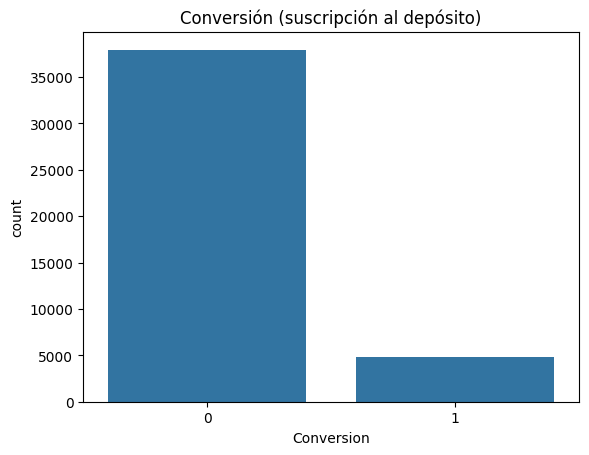

In [40]:
# Realizamos un conteo de la variable objetivo "Conversion" para saber cuántos clientes se suscribieron a un producto o servicio.
sns.countplot(data=df_limpio, x='Conversion')
plt.title('Conversión (suscripción al depósito)')
plt.show()

In [41]:
tasa_conversion = df_limpio['Conversion'].mean() * 100
print(tasa_conversion)

11.253274700598801


En este gráfico podemos ver que la tasa de converción es baja, debido a que la columna 1 (Si) es mucho más chica que la columna 0 (No). Además, si calculamos el porcentaje de conversión, podemos ver que el mismo es del 11,25%.

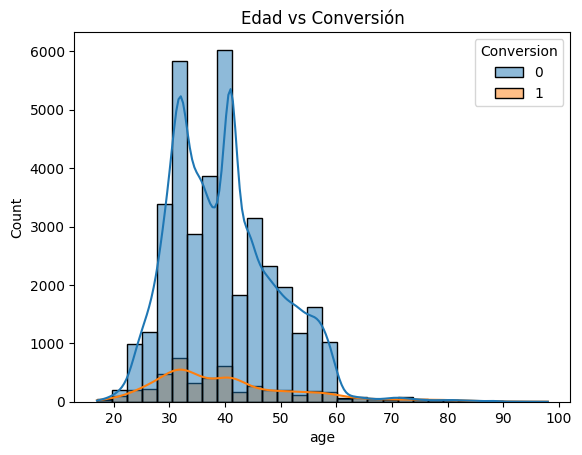

In [42]:
#En este gráfico comparamos la distribución de edades entre los clientes que se suscribieron (Conversion=1) y los que no se suscribieron (Conversion=0).

sns.histplot(data=df_limpio, x='age', hue='Conversion', bins=30, kde=True)
plt.title('Edad vs Conversión')
plt.show()

En este gráfico podemos ver que la mayoría de clientes (tanto los que convierten como los que no) están entre 30 y 50 años. La distribución de los que convierten (1) sigue una forma similar a los que no (0), pero parece haber ligeramente más peso en edades medias (30–45). En edades muy jóvenes (<25) y muy altas (>60) hay muy pocos casos de conversión.

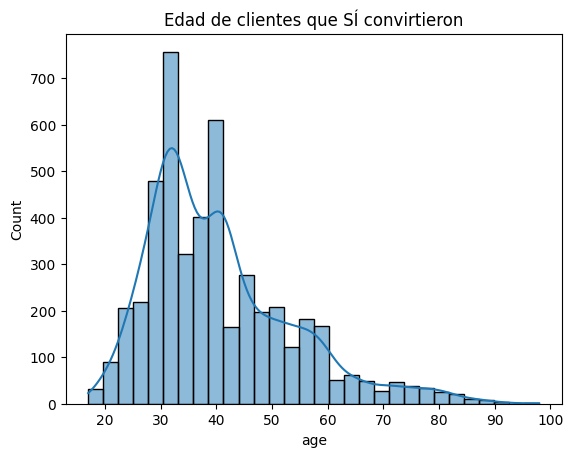

In [43]:
#Para analizar más a fondo la distribución de edades entre los clientes que se suscribieron, podemos filtrar a los clientes que tienen "Conversion" igual a 1, y luego graficar la distribución de edades.
df_conv = df_limpio[df_limpio['Conversion'] == 1]

sns.histplot(data=df_conv, x='age', bins=30, kde=True)
plt.title('Edad de clientes que SÍ convirtieron')
plt.show()

En este gráfico podemos deducir que la tasa de conversión es mayor entre las edades de 28 a 42 años.

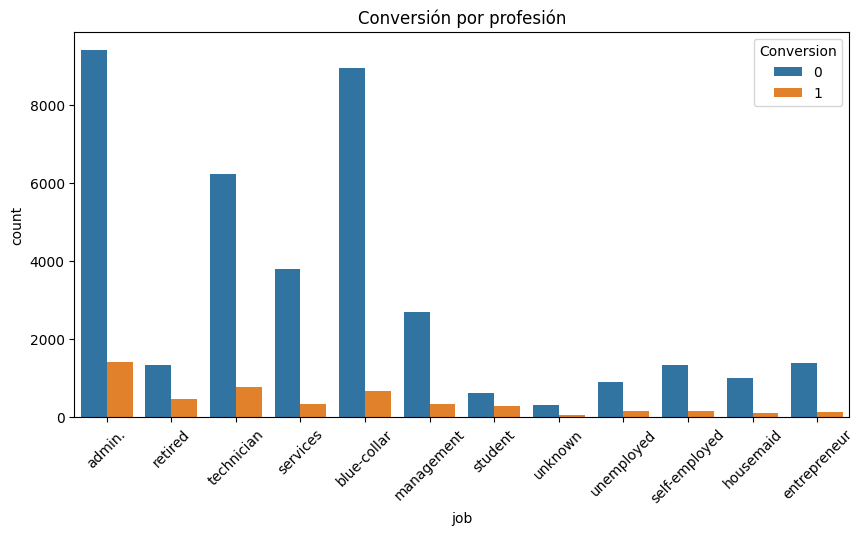

In [44]:
#En este gráfico comparamos la conversión por profesión, para ver si hay alguna profesión que tenga una mayor tasa de conversión que otras.

plt.figure(figsize=(10,5))
sns.countplot(data=df_limpio, x='job', hue='Conversion')
plt.xticks(rotation=45)
plt.title('Conversión por profesión')
plt.show()

En el gráfico podemos ver que la conversión es muy alta en personas con ocupación de administrador, técnico y trabajadores manuales. Sin embargo, también representan las categorias donde mayor tasa de participación hubo. Es necesario, para poder hacer un análisis más preciso, medir la tasa de conversión para evaluar la eficacia de la capaña.

In [ ]:
#Para poder realizar un gráfico más detallado de la conversión por profesión, podemos calcular la tasa de conversión para cada profesión, y luego graficar esa tasa de conversión.

resumen_job = df_limpio.groupby('job').agg({
    'Conversion': ['mean', 'count']
})

resumen_job.columns = ['tasa_conversion', 'cantidad_clientes']
resumen_job = resumen_job.sort_values(by='tasa_conversion', ascending=False)

resumen_job

,tasa_conversion,cantidad_clientes
job,,
student,0.313616,896
retired,0.252525,1782
unemployed,0.144476,1059
admin.,0.129791,10802
unknown,0.113372,344
management,0.111331,3036
self-employed,0.108564,1483
technician,0.108391,6984
housemaid,0.099373,1117


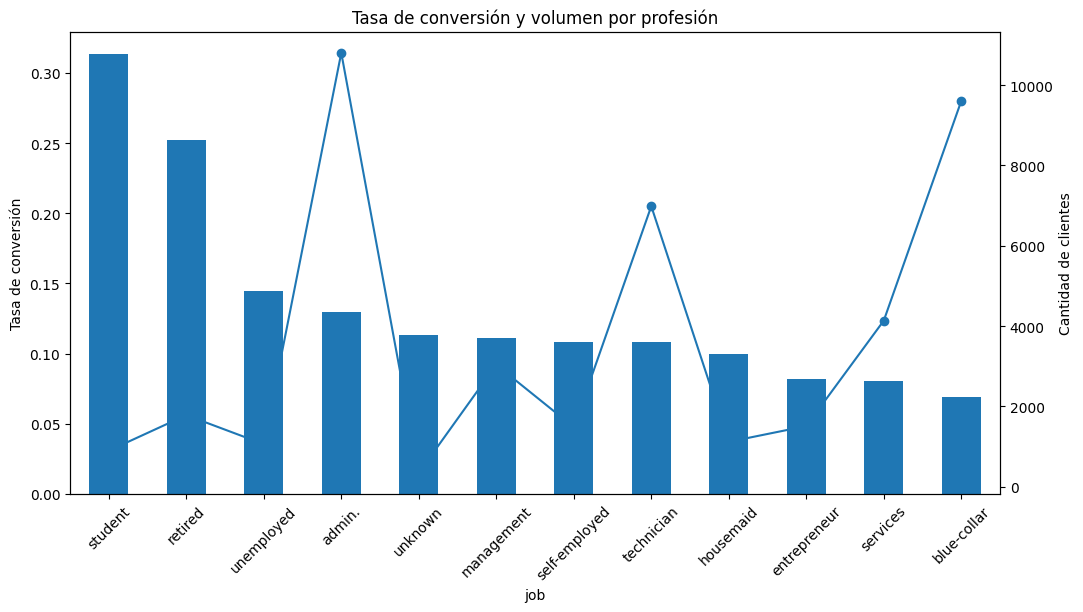

In [46]:
#Luego de calcular la tasa de conversión por profesión, podemos graficar esa tasa de conversión junto con la cantidad de clientes para cada profesión.

fig, ax1 = plt.subplots(figsize=(12,6))

resumen_job['tasa_conversion'].plot(kind='bar', ax=ax1)
ax1.set_ylabel('Tasa de conversión')
ax1.set_title('Tasa de conversión y volumen por profesión')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(resumen_job.index, resumen_job['cantidad_clientes'], marker='o')
ax2.set_ylabel('Cantidad de clientes')

plt.show()

El análisis muestra que los estudiantes y jubilados presentan las tasas de conversión más altas, aunque con menor volumen de clientes. Por otro lado, perfiles como administrativos y técnicos, aunque con tasas de conversión moderadas, representan los segmentos más relevantes en términos absolutos debido a su gran volumen. Finalmente, grupos como trabajadores manuales y servicios muestran baja eficiencia, ya que concentran muchos contactos pero generan pocas conversiones, lo que indica una posible necesidad de optimizar o reducir esfuerzos en estos segmentos.

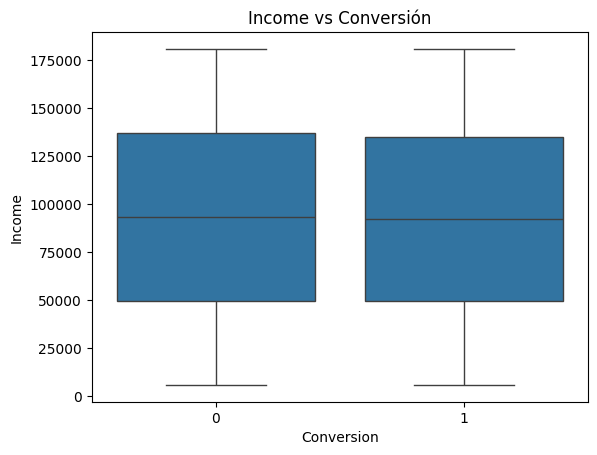

In [47]:
#En el siguiente gráfico comparamos la conversión con los ingresos de los clientes, para ver si hay una relación directa entre ambos.

sns.boxplot(data=df_limpio, x='Conversion', y='Income')
plt.title('Income vs Conversión')
plt.show()

No se observan diferencias significativas en la distribución de ingresos entre los clientes que suscriben el depósito y los que no. Esto sugiere que el nivel de ingresos no es un factor determinante en la conversión dentro de esta campaña.

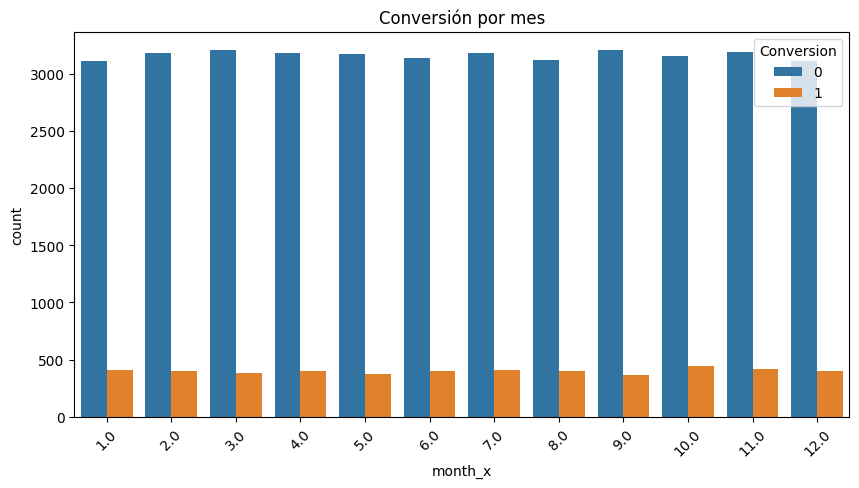

In [48]:
#En el siguiente gráfico vamos a comprar la conversión por mes, para detectar algún patrón relacionado con la fecha.

plt.figure(figsize=(10,5))
sns.countplot(data=df_limpio, x='month_x', hue='Conversion')
plt.xticks(rotation=45)
plt.title('Conversión por mes')
plt.show()

Este gráfico por si solo no nos muestra una diferencia significativa entre los meses de todos los años que estuvo activa la campaña, sin embargo, no podemos ver si hay variación entre los meses de cada año. 

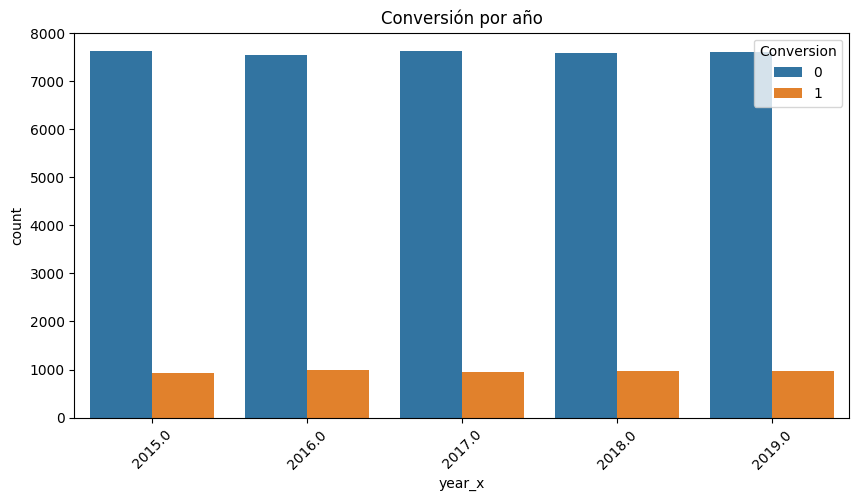

In [49]:
#En el siguiente gráfico vamos a comprar la conversión por año, para detectar algún patrón relacionado con la fecha.

plt.figure(figsize=(10,5))
sns.countplot(data=df_limpio, x='year_x', hue='Conversion')
plt.xticks(rotation=45)
plt.title('Conversión por año')
plt.show()

En este gráfico, vemos que no hay una diferencia marcada en la conversión si tenemos en cuenta el total de conversiones por año.

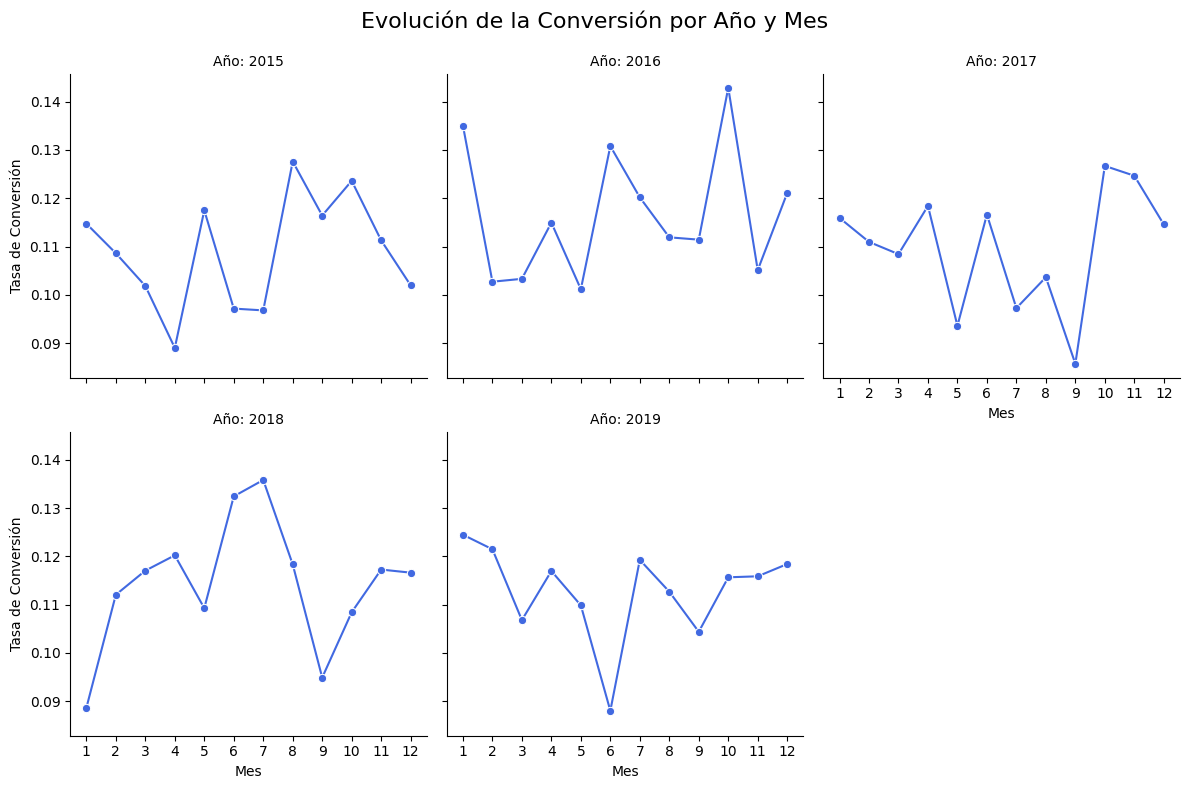

In [66]:
#Para poder analizar si hay algún patrón relacionada con la fecha de conversión, podemos crear un gráfico por año que relacione el mes de ese año con la conversión.

df_limpio['date'] = pd.to_datetime(df_limpio['date'])
df_limpio['year'] = df_limpio['date'].dt.year
df_limpio['month'] = df_limpio['date'].dt.month

df_mensual = df_limpio.groupby(['year', 'month'])['Conversion'].mean().reset_index()

g = sns.FacetGrid(df_mensual, col="year", col_wrap=3, height=4, sharey=True)
g.map(sns.lineplot, "month", "Conversion", marker="o", color="royalblue")

g.set_axis_labels("Mes", "Tasa de Conversión")
g.set_titles("Año: {col_name}")
g.set(xticks=range(1, 13))

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Evolución de la Conversión por Año y Mes', fontsize=16)

plt.show()

El análisis multianual confirma que la campaña presenta una estacionalidad cíclica, con debilidades recurrentes al final del tercer trimestre (Septiembre) y recuperaciones hacia el cierre del año. Sin embargo, la consistencia de los rangos de conversión entre 2015 y 2019 sugiere que los factores externos macroeconómicos y la ejecución de la llamada tienen un peso mayor que el simple paso de los meses.

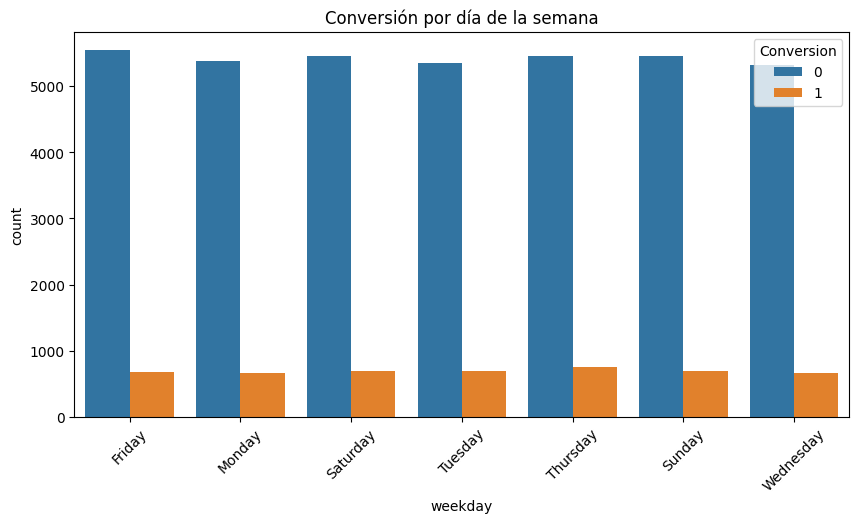

In [ ]:
#En el siguiente gráfico vamos a comprar la conversión por día de la semana, para detectar algún patrón relacionado con el día en el que suelen contratar los clientes.

plt.figure(figsize=(10,5))
sns.countplot(data=df_limpio, x='weekday', hue='Conversion')
plt.xticks(rotation=45)
plt.title('Conversión por día de la semana')
plt.show()

En este último gráfico no detectamos un patrón de conversión relacionado con el día de la semana en el que suelen contratar los clientes.

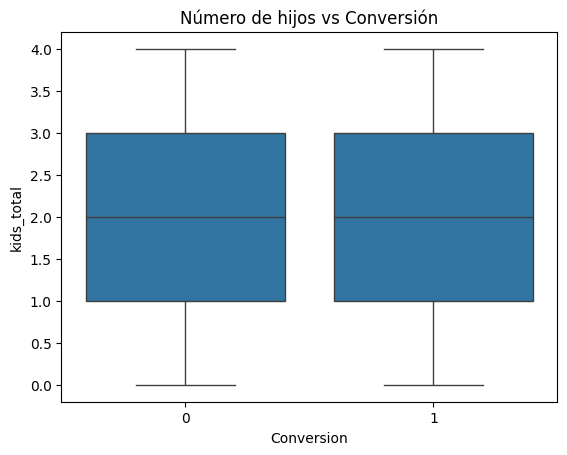

In [51]:
#En este gráfico, vamos a comprar al conversión con el número total de hijo que tiene cada cliente.

df_limpio['kids_total'] = df_limpio['Kidhome'] + df_limpio['Teenhome']

sns.boxplot(data=df_limpio, x='Conversion', y='kids_total')
plt.title('Número de hijos vs Conversión')
plt.show()

En este gráfico, tampoco vemos una relación clara entre el número total de hijos y la conversión, ya que la distribución de "kids_total" es similar tanto para los clientes que se suscribieron (Conversion=1) como para los que no se suscribieron (Conversion=0). Esto sugiere que el número de hijos no es un factor determinante en la decisión de suscribirse al producto o servicio ofrecido por el banco.

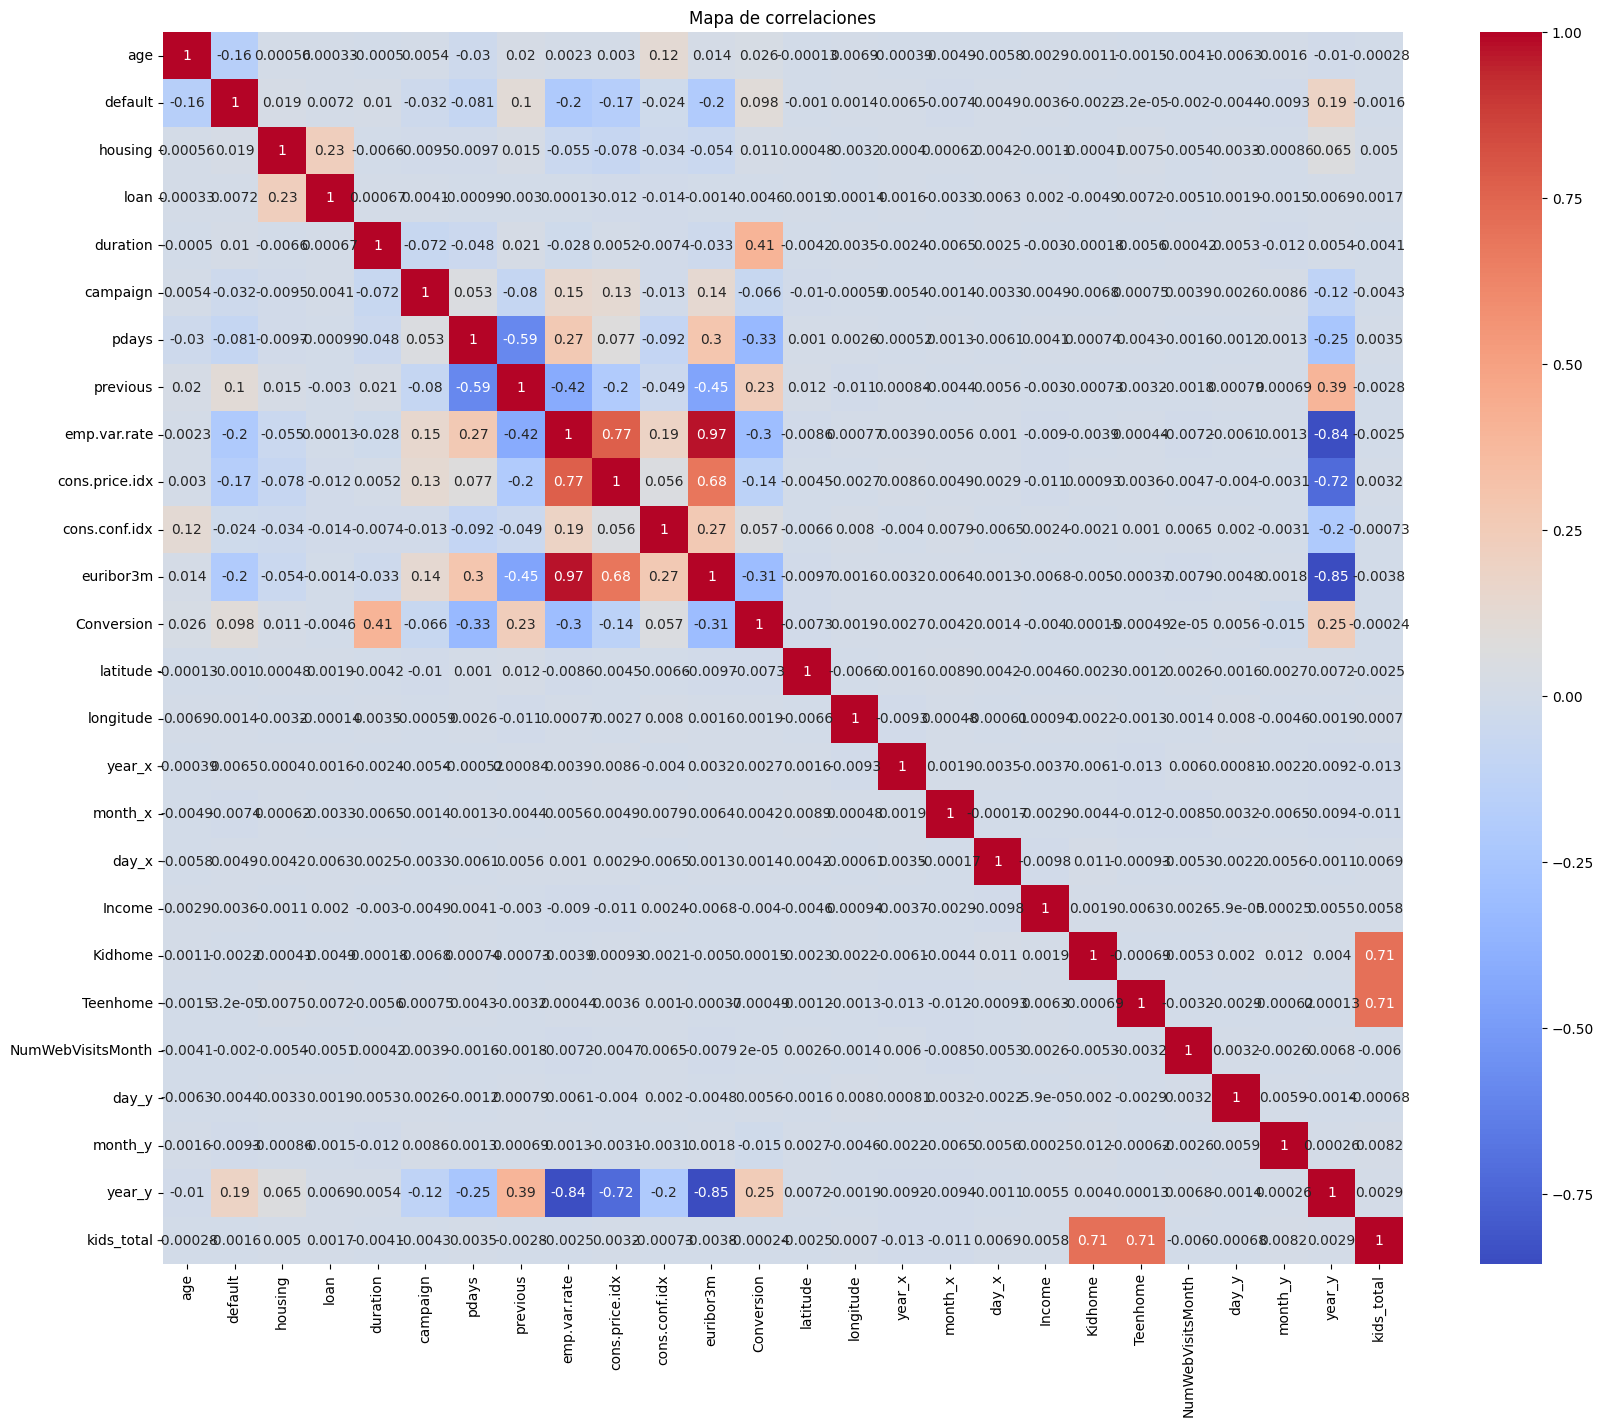

In [52]:
#Para analizar las correlaciones entre las variables numéricas y poder ver de una forma simple y visual que variables tiene relaciones más fuertes, podemos crear un mapa de calor de correlaciones utilizando la función heatmap de seaborn.

corr = df_limpio.select_dtypes(include='number').corr()

plt.figure(figsize=(20,16))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de correlaciones')
plt.show()

En este mapa de calor, podemos ver que la correlación más fuerte para la variable que nos interesa es con la duración de la llamada, entre más tiempo de duración más tasa de conversión. Por otro lado, también vemos una relación inversamente proporcional muy fuerte entre el pday y la conversión, cuantos menos días pasaron desde el último contacto, mayor es la probabilidad de éxito. Finalmente, en cuanto al euribor, vemos que tiene una correlación negativa, cuando el eurobor baja (menor tasa de interés en el mercado) la conversión aumenta.

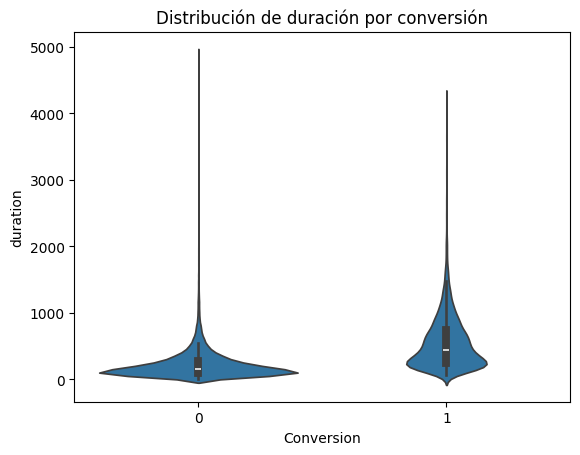

In [ ]:
#En el mapa de calir vemos una fuerte correlación entre la duración de las llamadas y la conversión, para ver la relación de forma más gráfica podemos graficarlo en un gráfico tipo violin.

sns.violinplot(data=df_limpio, x='Conversion', y='duration')
plt.title('Distribución de duración por conversión')
plt.show()

En este gráfico podemos validar lo indicado por el mapa de calor, ya que visualizamos como la duración de las llamadas de los clientes que se han suscripto tienen tendencia a ser más largas que aquellos que no se han suscripto.

<Axes: title={'center': 'Tasa de Éxito por Duración'}, xlabel='segmento_duracion'>

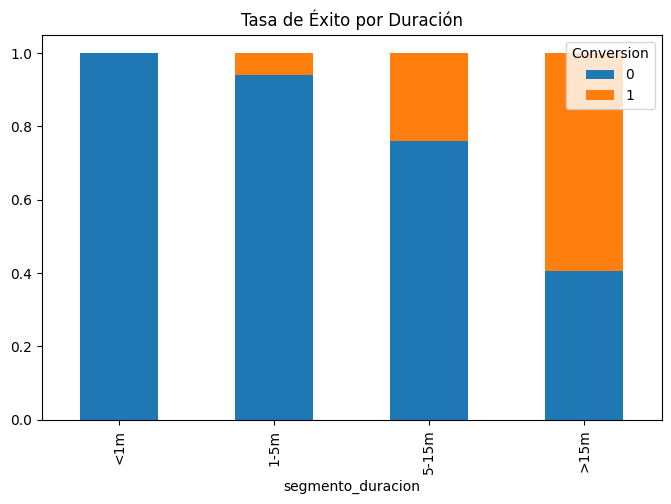

In [ ]:
#Luego de identificar que la duración de la llamada tiene una fuerte correlación con la conversión, podemos segmentar la variable "duración" en categorias para analizar mejor su relación con la conversión. Luego, realizamos un gráfico de barras apiladas para visualizar la tasa de éxito por cada segmento de duración.

bins = [0, 60, 300, 900, df_limpio['duration'].max()]
labels = ['<1m', '1-5m', '5-15m', '>15m']
df_limpio['segmento_duracion'] = pd.cut(df_limpio['duration'], bins=bins, labels=labels)

tabla = pd.crosstab(df_limpio['segmento_duracion'], df_limpio['Conversion'], normalize='index')
tabla.plot(kind='bar', stacked=True, figsize=(8,5), title='Tasa de Éxito por Duración')

En este gráfico, podemos ver como la tasa de conversión en llamadas de menos de un minuto es nula y como aumenta a medida que la llamada es más larga. Además, pese a haber pocas llamadas de más de 15 minutos, la tasa de conversión es alta, por lo que, una llamada más larga no asegura la suscripción pero tiene una alta probabilidad de generar un nuevo cliente frente a llamadas de menos de 5 minutos.

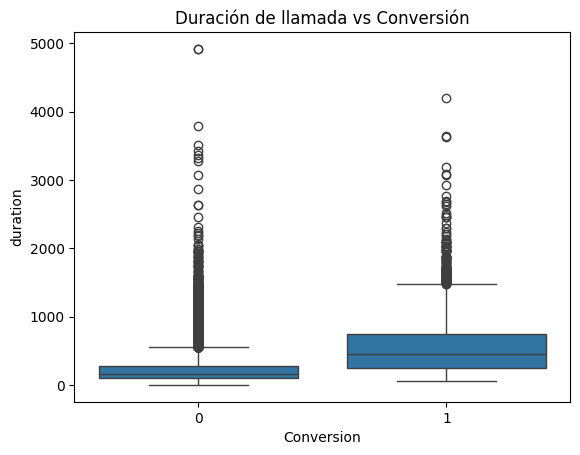

In [55]:
# Otro gráfico que nos sirve para ver la distribución de clientes por duración de llamada y su relación con la conversión, es un boxplot que compara la duración de las llamadas entre los clientes que se suscribieron (Conversion=1) y los que no se suscribieron (Conversion=0).

sns.boxplot(data=df_limpio, x='Conversion', y='duration')
plt.title('Duración de llamada vs Conversión')
plt.show()

En este gráfico vemos como la media de duración de llamadas de los clientes que convirtieron (1) es mayor que la de los clientes que no lo hicieron (0). Además, se pueden identificar de forma más clara los outliers o valores atípicos, pero aun así la tendencia de éxito se mantiene alta.

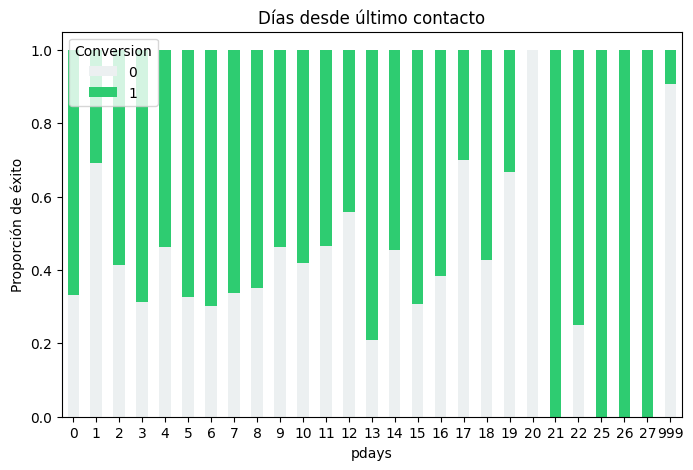

In [ ]:
#Para evaluar el impacto de la variable "pdays" (días desde el último contacto) en la conversión, podemos crear un gráfico de barras apiladas que muestre la tasa de éxito para cada valor de "pdays".
tabla_pdays = pd.crosstab(df_limpio['pdays'], df_limpio['Conversion'], normalize='index')

tabla_pdays.plot(kind='bar', stacked=True, color=['#ecf0f1', '#2ecc71'], figsize=(8,5))
plt.title('Días desde último contacto')
plt.ylabel('Proporción de éxito')
plt.xticks(rotation=0)
plt.show()

En este gráfico, podemos visualizar que aunque la mayoría de los usuarios están concetrados en el grupo de clientes nunca antes contactados "999", su probabilidad de decir "sí" es bajísima. Por otro lado, si un cliente ya fue contactado hace poco, la probabilidad de que convierta es mucho mayor comparada con un cliente nuevo.

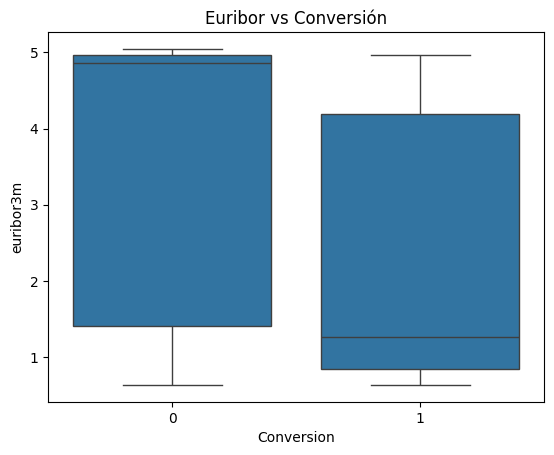

In [56]:
#Para poder evaluar como el contexto económico impacta en la conversión, podemos analizar la variable "euribor3m", que es una tasa de interés de referencia en el mercado financiero. Podemos comparar la distribución de "euribor3m" entre los clientes que se suscribieron (Conversion=1) y los que no se suscribieron (Conversion=0) utilizando un boxplot.

sns.boxplot(data=df_limpio, x='Conversion', y='euribor3m')
plt.title('Euribor vs Conversión')
plt.show()

La información que podemos extraer tanto del mapa de calor como del boxplot en relación a la correlación entre el euribor y la tasa de conversión es muy útil, ya que podemos ver como los clientes son mucho más propensos a convertir cuando las tasas de interés están bajas. Esto lo podemos deducir viendo las mediandas de ambos grupos, en el grupo de conversión 0 la mediana está elevada, cerca de los 5 puntos y en el grupo de conversión 1 la mediana está cerca de 1.